## **Week 4** (EDA Deep Dive) Univariate and Bivariate Analysis

**Project:** Crime Hotspot Mapping | **Dataset:** Cleaned global country-level indicators (`CLEANED_DATASET`)

The cleaned dataset holds socio-economic, demographic and health indicators for countries around the world, together with the **homicide rate**, which is the crime indicator used as the focus of this analysis. The goal of this notebook is to (1) understand each variable on its own (univariate) and (2) understand how homicide and the other indicators relate to each other (bivariate).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

In [2]:
# NOTE: the file is a CSV even though it carries an .xls extension.
# In Google Colab use the path: '/content/CLEANED_DATASET__1__csv.xls'
df = pd.read_csv('CLEANED_DATASET__1__csv.xls')

In [3]:
df.head()

,name,region,iso2,population,pop_density,life_expectancy_male,life_expectancy_female,sex_ratio,gdp_per_capita,gdp_growth,unemployment,infant_mortality,fertility,homicide_rate,urban_population,internet_users,secondary_school_enrollment_female,secondary_school_enrollment_male,co2_emissions,forested_area
0,Afghanistan,Southern Asia,AF,38928,59.6,62.80,65.8,105.4,551.9,-1.7,11.2,51.70,4.6,6.7,25.8,13.5,40.0,70.1,31.3,2.1
1,Albania,Southern Europe,AL,2878,105.0,76.70,80.1,103.7,5223.8,4.1,12.8,8.00,1.6,2.3,61.2,71.8,95.7,95.2,4.3,28.2
2,Algeria,Northern Africa,DZ,43851,18.4,75.40,77.8,102.1,4114.7,1.4,11.5,21.20,3.0,1.4,73.2,49.0,101.5,97.8,130.5,0.8
3,Andorra,Southern Europe,AD,77,164.2,70.65,76.7,102.3,42051.6,1.6,5.4,14.35,1.2,0.0,88.0,91.6,91.6,88.4,31.3,34.0
4,Angola,Middle Africa,AO,32866,26.4,57.80,63.4,97.9,3437.3,-1.2,6.8,61.50,5.6,4.8,66.2,14.3,39.7,61.8,18.0,46.4


In [4]:
df.shape

(204, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   name                                204 non-null    str    
 1   region                              204 non-null    str    
 2   iso2                                204 non-null    str    
 3   population                          204 non-null    int64  
 4   pop_density                         204 non-null    float64
 5   life_expectancy_male                204 non-null    float64
 6   life_expectancy_female              204 non-null    float64
 7   sex_ratio                           204 non-null    float64
 8   gdp_per_capita                      204 non-null    float64
 9   gdp_growth                          204 non-null    float64
 10  unemployment                        204 non-null    float64
 11  infant_mortality                    204 non-null    floa

In [6]:
df.isnull().sum()

name                                  0
region                                0
iso2                                  0
population                            0
pop_density                           0
life_expectancy_male                  0
life_expectancy_female                0
sex_ratio                             0
gdp_per_capita                        0
gdp_growth                            0
unemployment                          0
infant_mortality                      0
fertility                             0
homicide_rate                         0
urban_population                      0
internet_users                        0
secondary_school_enrollment_female    0
secondary_school_enrollment_male      0
co2_emissions                         0
forested_area                         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(12)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
population,204.0,39678.039216,144329.797808,1.0,2082.000,9227.50,31532.750,1439324.0
pop_density,204.0,335.172549,1940.442342,2.1,34.825,88.60,203.875,26373.8
life_expectancy_male,204.0,69.845588,7.324206,50.4,64.825,70.65,75.100,81.7
life_expectancy_female,204.0,74.706863,7.722072,54.8,69.175,76.70,80.100,87.5
sex_ratio,204.0,102.612745,22.224709,84.5,96.600,99.15,101.725,302.4
gdp_per_capita,204.0,15839.619118,25458.479886,99.6,2018.025,5930.10,17395.050,185835.0
gdp_growth,204.0,3.127451,3.142013,-18.0,1.700,3.00,4.800,17.9
unemployment,204.0,7.203431,5.359328,0.1,3.800,5.40,9.725,30.6
infant_mortality,204.0,21.641667,19.516263,1.3,6.225,14.35,33.400,81.9
fertility,204.0,2.727941,1.271341,1.1,1.800,2.30,3.600,7.0


In [9]:
df.columns.tolist()

['name',
 'region',
 'iso2',
 'population',
 'pop_density',
 'life_expectancy_male',
 'life_expectancy_female',
 'sex_ratio',
 'gdp_per_capita',
 'gdp_growth',
 'unemployment',
 'infant_mortality',
 'fertility',
 'homicide_rate',
 'urban_population',
 'internet_users',
 'secondary_school_enrollment_female',
 'secondary_school_enrollment_male',
 'co2_emissions',
 'forested_area']

**Data Preparation**

The duplicate check above shows that the cleaned file still contains exact duplicate rows (each affected country appears twice). These are removed before any analysis so that no country is counted twice in the distributions or correlations.

In [10]:
print('Rows before:', len(df))
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after :', len(df))
print('Unique countries:', df['name'].nunique())

Rows before: 204
Rows after : 192
Unique countries: 192


**Data-quality flag:** the ISO code column should be unique per country. Checking it:

In [11]:
df[df['iso2'].duplicated(keep=False)][['name', 'iso2', 'region']]

,name,iso2,region
3,Andorra,AD,Southern Europe
121,Namibia,AD,Southern Africa


Namibia is recorded with the code `AD`, which belongs to Andorra (Namibia's ISO code is `NA`). This does not affect any analysis in this notebook because countries are identified by `name` and `region`, but the code should be corrected before it is used for map-based hotspot visualisation.

**Derived feature:** the homicide rate is grouped into four levels so that countries can be summarised in plain categories.

In [12]:
num_cols = df.select_dtypes(include='number').columns.tolist()

df['homicide_level'] = pd.cut(
    df['homicide_rate'],
    bins=[-0.01, 2, 10, 20, np.inf],
    labels=['Low (<=2)', 'Moderate (>2-10)', 'High (>10-20)', 'Very high (>20)']
)

df['homicide_level'].value_counts().sort_index()

homicide_level
Low (<=2)           68
Moderate (>2-10)    91
High (>10-20)       14
Very high (>20)     19
Name: count, dtype: int64

**Data-quality check: repeated values**

Before analysing distributions, it is worth checking whether any single value is repeated suspiciously often, since that can be a sign of missing values having been filled with a placeholder (such as the median) during cleaning.

In [13]:
repeat_check = []
for c in num_cols:
    vc = df[c].value_counts()
    repeat_check.append({'variable': c, 'most common value': vc.index[0],
                         'countries with that value': vc.iloc[0],
                         '% of countries': round(vc.iloc[0] / len(df) * 100, 1)})

pd.DataFrame(repeat_check).sort_values('countries with that value', ascending=False).head(8).reset_index(drop=True)

,variable,most common value,countries with that value,% of countries
0,co2_emissions,31.30,57,29.7
1,homicide_rate,2.50,26,13.5
2,secondary_school_enrollment_female,91.60,15,7.8
3,fertility,1.80,14,7.3
4,secondary_school_enrollment_male,88.40,13,6.8
5,unemployment,5.40,12,6.2
6,gdp_growth,4.10,8,4.2
7,infant_mortality,14.35,7,3.6


In [14]:
# Which regions do the homicide_rate = 2.5 rows belong to?
print('Countries with homicide_rate exactly 2.5:', (df['homicide_rate'] == 2.5).sum())
df.loc[df['homicide_rate'] == 2.5, 'region'].value_counts().head(6)

Countries with homicide_rate exactly 2.5: 26


region
Western Africa    6
Middle Africa     5
Eastern Africa    5
Micronesia        3
Eastern Europe    1
Southern Asia     1
Name: count, dtype: int64

Two variables stand out. `co2_emissions` has the value 31.3 for 57 countries (30%), and `homicide_rate` has the value 2.5 for 26 countries (14%). In both cases the repeated value is the column median, which is consistent with **median imputation** of missing values during cleaning. The 2.5 homicide values sit mainly in Western, Middle and Eastern Africa, where official crime statistics are often unavailable.

These repeated values are kept in the analysis (the dataset is used as provided), but they are kept in mind when reading the results: they create a spike at 2.5 in the homicide histogram, a flat band in the scatter plots, and they pull some regional medians towards 2.5. A sensitivity check at the end of the bivariate section tests whether the conclusions still hold without them.

**Univariate** **Analysis**

Univariate analysis examines one variable at a time to understand its distribution, frequency, and basic characteristics.

**Skewness overview** of all numeric variables (a value near 0 is symmetric; a large positive value means a long right tail):

In [15]:
summary = df[num_cols].agg(['mean', 'median', 'std', 'skew']).T.round(2)
summary.sort_values('skew', ascending=False)

,mean,median,std,skew
pop_density,350.61,87.75,1999.39,12.01
co2_emissions,171.09,31.30,776.30,9.71
population,40329.92,8976.50,148622.05,8.37
sex_ratio,102.90,99.20,22.85,5.79
gdp_per_capita,15536.08,5862.35,25716.87,3.73
homicide_rate,6.54,2.50,9.86,2.52
unemployment,7.07,5.40,5.42,1.61
infant_mortality,21.95,14.35,19.53,1.08
fertility,2.75,2.30,1.27,0.95
forested_area,32.10,31.65,23.57,0.50


Most variables are **right-skewed**, with the strongest skew in `pop_density` (12.0), `co2_emissions` (9.7), `population` (8.4), `sex_ratio` (5.8) and `gdp_per_capita` (3.7). The target variable `homicide_rate` is also clearly right-skewed (2.5). Health and education variables such as life expectancy and school enrollment lean slightly the other way (negative skew). Because of this, the **median** is used alongside the mean in the charts that follow.

**Histogram + Box Plot** of Homicide Rate:

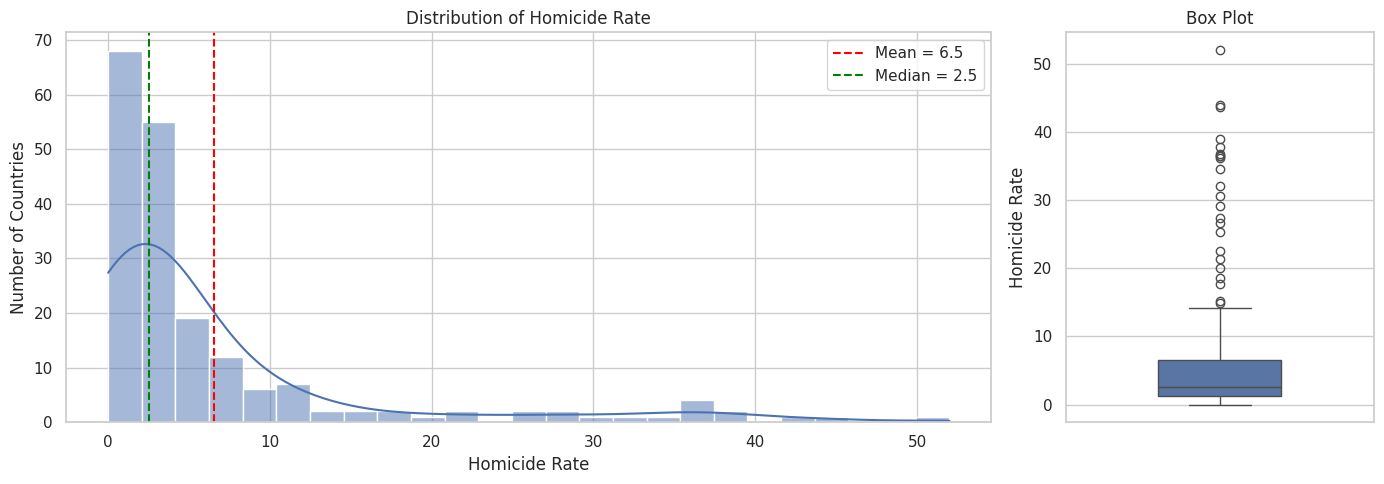

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

sns.histplot(df['homicide_rate'], bins=25, kde=True, ax=axes[0])
axes[0].axvline(df['homicide_rate'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['homicide_rate'].mean():.1f}")
axes[0].axvline(df['homicide_rate'].median(), color='green', linestyle='--',
                label=f"Median = {df['homicide_rate'].median():.1f}")
axes[0].set_title('Distribution of Homicide Rate')
axes[0].set_xlabel('Homicide Rate')
axes[0].set_ylabel('Number of Countries')
axes[0].legend()

sns.boxplot(y=df['homicide_rate'], ax=axes[1], width=0.4)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Homicide Rate')

plt.tight_layout()
plt.show()

In [17]:
q1, q3 = df['homicide_rate'].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
outliers = df[df['homicide_rate'] > upper_fence]

print(f'Upper outlier fence (Q3 + 1.5*IQR): {upper_fence:.2f}')
print(f'Countries above the fence: {len(outliers)}')
outliers.nlargest(10, 'homicide_rate')[['name', 'region', 'homicide_rate']]

Upper outlier fence (Q3 + 1.5*IQR): 14.43
Countries above the fence: 23


,name,region,homicide_rate
52,El Salvador,Central America,52.0
84,Jamaica,Caribbean,43.9
97,Lesotho,Southern Africa,43.6
73,Honduras,Central America,38.9
17,Belize,Central America,37.8
187,"Venezuela, Bolivarian Republic Of",South America,36.7
146,Saint Vincent And The Grenadines,Caribbean,36.5
160,South Africa,Southern Africa,36.4
144,Saint Kitts And Nevis,Caribbean,36.1
128,Nigeria,Western Africa,34.5


**Observation:** the distribution is strongly right-skewed. The mean (6.5) is far above the median (2.5), and 75% of countries have a rate of 6.6 or below, yet the maximum reaches 52.0 (El Salvador). 23 countries lie above the upper outlier fence of 14.4. Grouped by level, 68 countries are Low, 91 Moderate, 14 High and 19 Very high, so about 83% of countries sit at a rate of 10 or below while a small group forms a heavy upper tail. The tall bar at about 2.5 is partly the 26 countries that share exactly that value (see the data-quality check above).

**Count Plot** of Countries per Region:

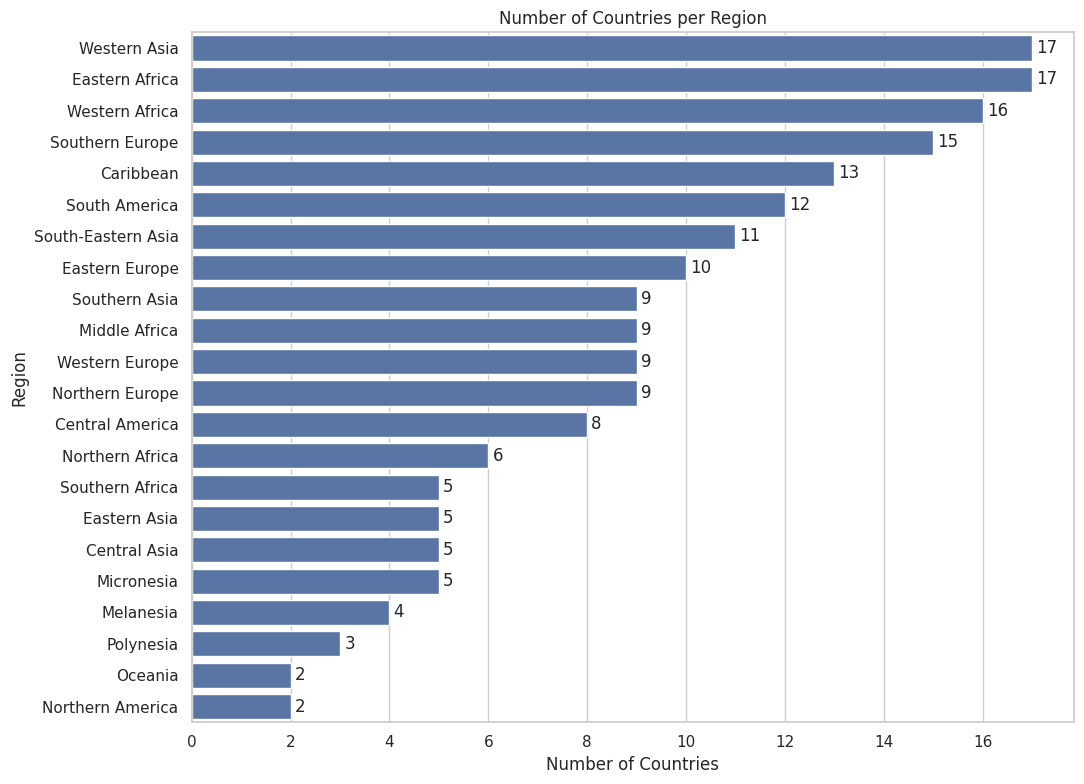

In [18]:
plt.figure(figsize=(11, 8))

ax = sns.countplot(
    y='region',
    data=df,
    order=df['region'].value_counts().index,
    color=sns.color_palette()[0]
)
ax.bar_label(ax.containers[0], padding=3)

plt.title('Number of Countries per Region')
plt.xlabel('Number of Countries')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

**Observation:** the 192 countries are spread over 22 regions, but unevenly. Western Asia and Eastern Africa are the largest (17 countries each), followed by Western Africa (16), Southern Europe (15) and the Caribbean (13). Northern America and Oceania have only 2 countries each, so any regional average for these small regions should be read with caution.

**Histograms** of Key Socio-Economic Indicators:

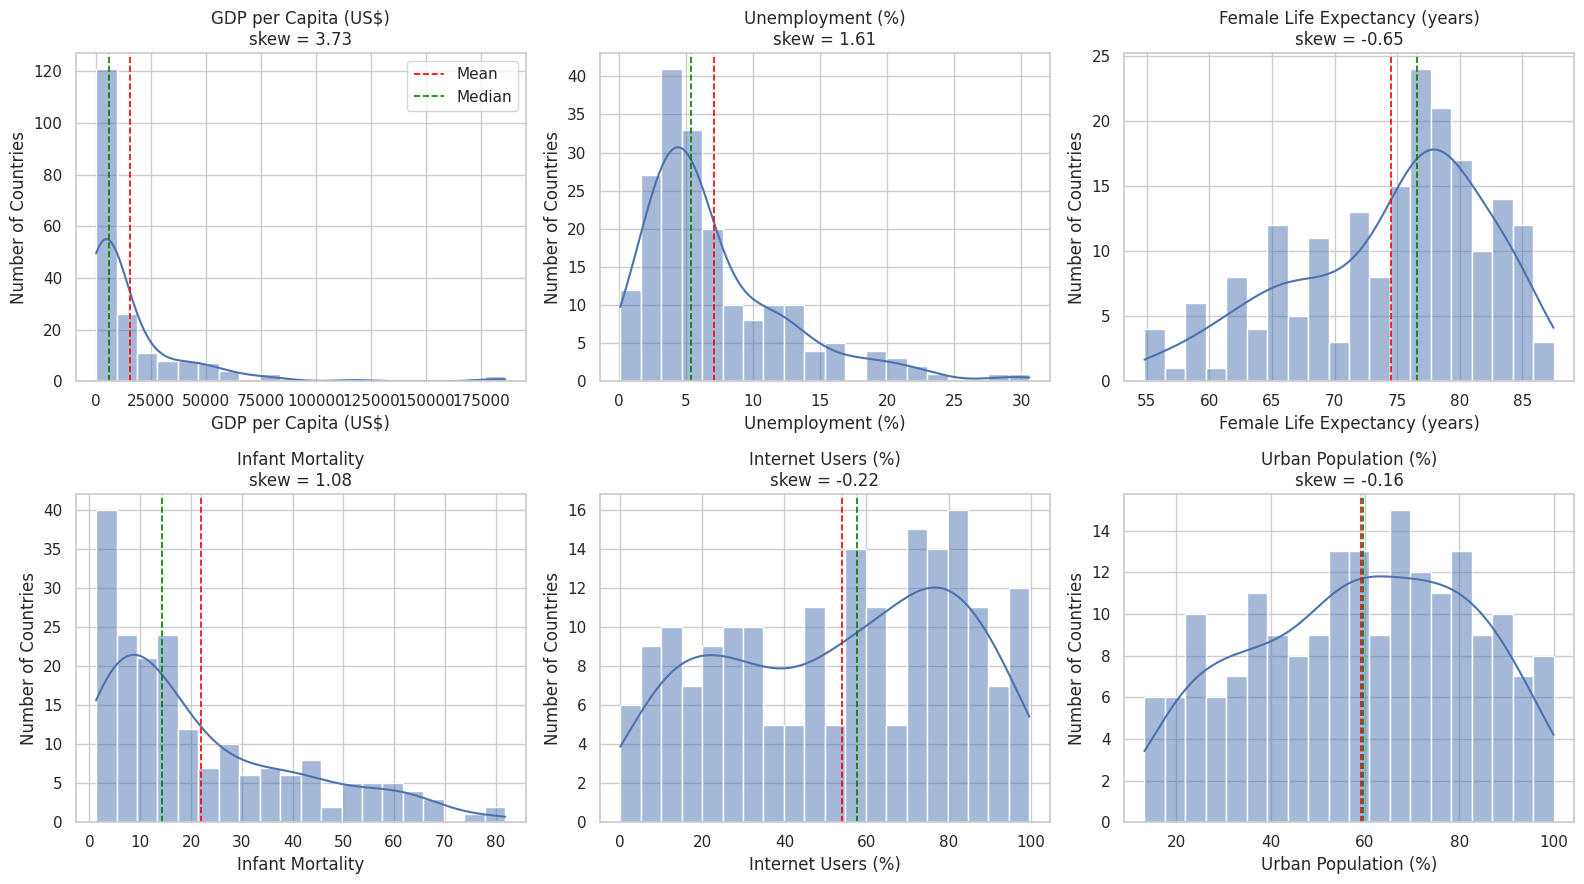

In [19]:
key_vars = {
    'gdp_per_capita': 'GDP per Capita (US$)',
    'unemployment': 'Unemployment (%)',
    'life_expectancy_female': 'Female Life Expectancy (years)',
    'infant_mortality': 'Infant Mortality',
    'internet_users': 'Internet Users (%)',
    'urban_population': 'Urban Population (%)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (col, label) in zip(axes.ravel(), key_vars.items()):
    sns.histplot(df[col], bins=20, kde=True, ax=ax)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1.2, label='Median')
    ax.set_title(f'{label}\nskew = {df[col].skew():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Countries')

axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Observation:** the six indicators have very different shapes.
- `gdp_per_capita` is extremely right-skewed (skew 3.7): the mean (about US$15,500) is nearly three times the median (about US$5,900), because a few wealthy economies stretch the tail.
- `unemployment` (skew 1.6) and `infant_mortality` (skew 1.1) are also right-skewed, with most countries at low values and a smaller group at high values.
- `life_expectancy_female` is left-skewed (-0.65), with about two-thirds of countries between 70 and 85 years and a tail of low-life-expectancy countries.
- `internet_users` is spread widely across the whole 0-100% range, while `urban_population` is close to symmetric (mean 59.1, median 59.5).

# **BIVARIATE** **ANALYSIS**

Bivariate analysis examines the relationship between two variables to identify patterns, associations, and differences between them.

**Heatmap** of Correlations between all Numeric Variables:

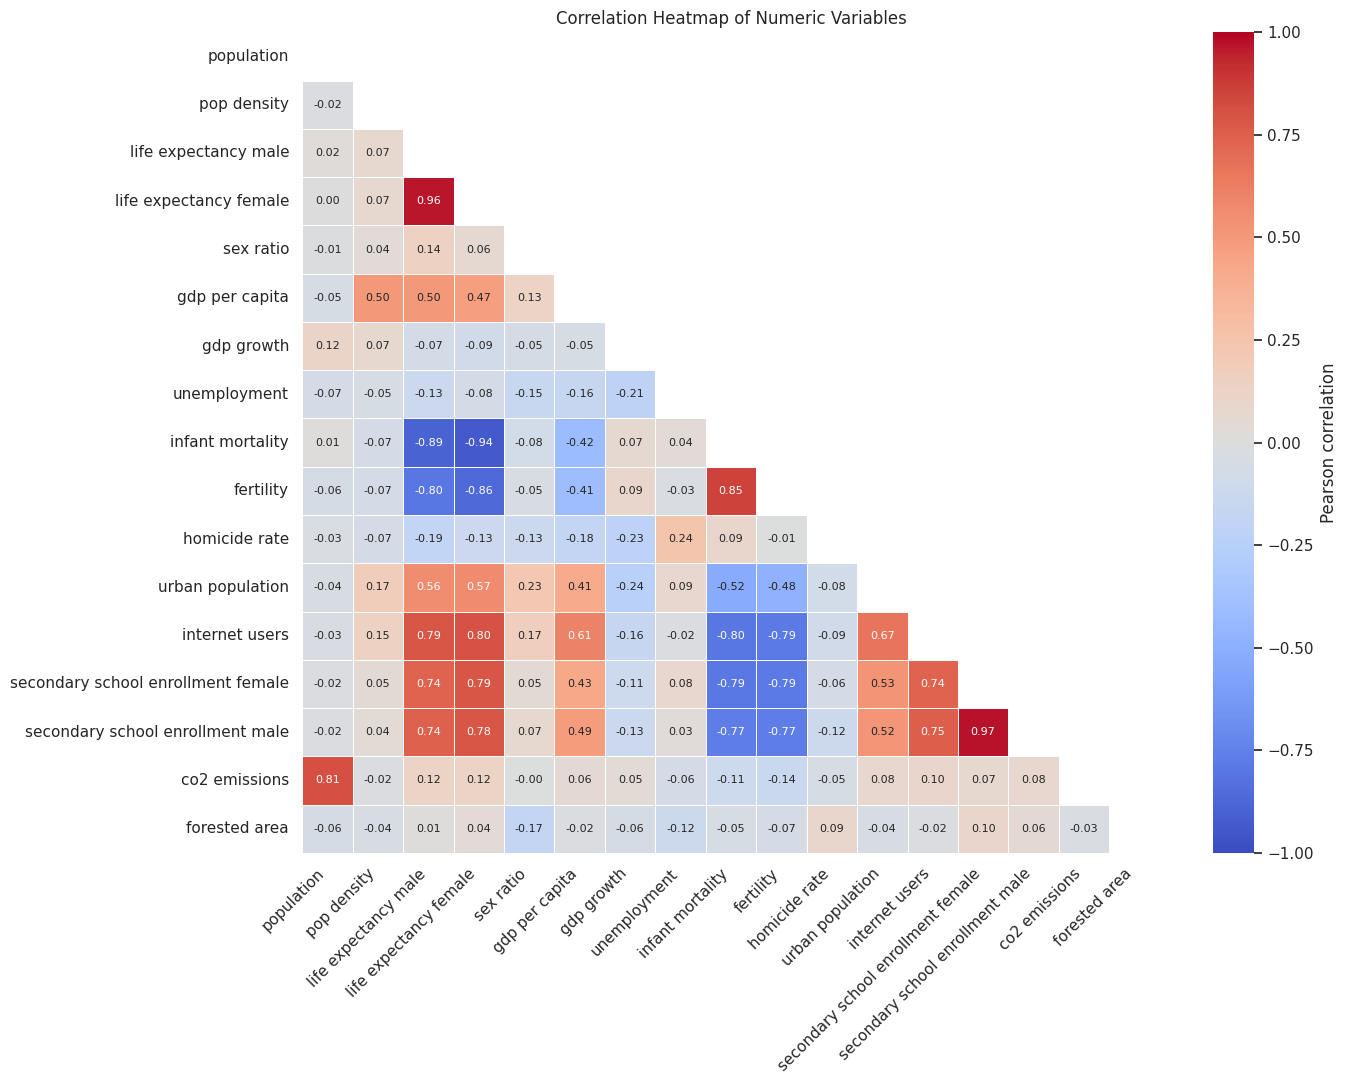

In [20]:
corr = df[num_cols].corr()
labels = [c.replace('_', ' ') for c in corr.columns]
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, cbar_kws={'label': 'Pearson correlation'}
)

plt.gca().grid(False)
plt.title('Correlation Heatmap of Numeric Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# Strongest pairs of variables
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(8).round(2)

secondary_school_enrollment_female  secondary_school_enrollment_male    0.97
life_expectancy_male                life_expectancy_female              0.96
life_expectancy_female              infant_mortality                   -0.94
life_expectancy_male                infant_mortality                   -0.89
life_expectancy_female              fertility                          -0.86
infant_mortality                    fertility                           0.85
population                          co2_emissions                       0.81
infant_mortality                    internet_users                     -0.80
dtype: float64

In [22]:
# Homicide rate: linear (Pearson) vs rank-based (Spearman) correlation
comparison = pd.DataFrame({
    'Pearson': df[num_cols].corr()['homicide_rate'],
    'Spearman': df[num_cols].corr(method='spearman')['homicide_rate']
}).drop('homicide_rate').round(2)

comparison.sort_values('Spearman')

,Pearson,Spearman
life_expectancy_male,-0.19,-0.43
life_expectancy_female,-0.13,-0.39
internet_users,-0.09,-0.37
gdp_per_capita,-0.18,-0.33
urban_population,-0.08,-0.30
secondary_school_enrollment_male,-0.12,-0.29
secondary_school_enrollment_female,-0.06,-0.24
pop_density,-0.07,-0.21
co2_emissions,-0.05,-0.19
gdp_growth,-0.23,-0.10


**Observation:** many indicators are strongly linked to each other. The strongest pairs are male and female school enrollment (0.97), male and female life expectancy (0.96), female life expectancy and infant mortality (-0.94), infant mortality and fertility (0.85), and population and CO2 emissions (0.81). This overlap (multicollinearity) is worth remembering before any modelling.

`homicide_rate`, in contrast, is only weakly correlated with every other variable. On the Pearson scale the largest values are unemployment (+0.24) and GDP growth (-0.23). The rank-based Spearman correlation, which is less affected by extreme values, is somewhat stronger: male life expectancy (-0.43), infant mortality (+0.41), internet users (-0.37), fertility (+0.34) and GDP per capita (-0.33).

**Scatter Plots** of Homicide Rate vs Key Indicators:

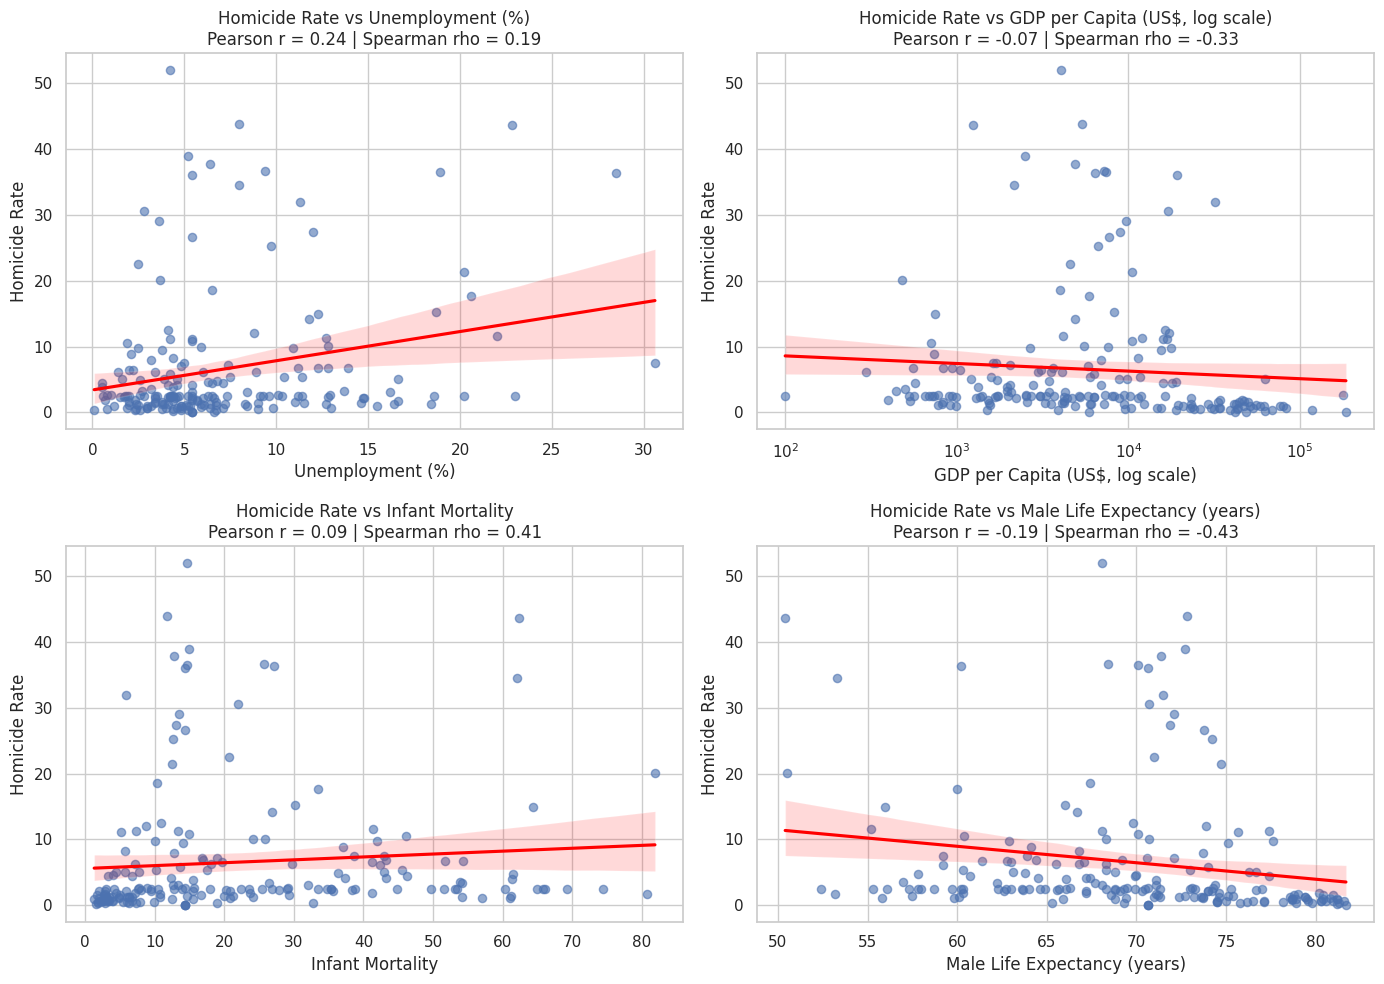

In [23]:
pairs_xy = [
    ('unemployment', 'Unemployment (%)'),
    ('gdp_per_capita', 'GDP per Capita (US$, log scale)'),
    ('infant_mortality', 'Infant Mortality'),
    ('life_expectancy_male', 'Male Life Expectancy (years)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, label) in zip(axes.ravel(), pairs_xy):
    is_gdp = (col == 'gdp_per_capita')
    sns.regplot(
        x=col, y='homicide_rate', data=df, ax=ax, logx=is_gdp,
        scatter_kws={'alpha': 0.6, 's': 35}, line_kws={'color': 'red'}
    )
    if is_gdp:
        ax.set_xscale('log')

    x = np.log10(df[col]) if is_gdp else df[col]
    r = np.corrcoef(x, df['homicide_rate'])[0, 1]
    rho = stats.spearmanr(df[col], df['homicide_rate'])[0]

    ax.set_title(f'Homicide Rate vs {label}\nPearson r = {r:.2f} | Spearman rho = {rho:.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Homicide Rate')

plt.tight_layout()
plt.show()

**Observation:** all four relationships are weak to moderate and wide scatter remains around every trend line. Homicide tends to be lower in countries with higher male life expectancy (Spearman -0.43) and higher GDP per capita (-0.33), and higher where infant mortality (+0.41) and unemployment (+0.19) are higher. For GDP per capita and infant mortality the Pearson value (-0.07 and +0.09) is much weaker than the Spearman value, which means the link is not a straight line: the highest homicide rates come from a cluster of middle-income countries rather than from the very poorest, so a single indicator cannot explain them. The flat band of points at a rate of 2.5 in every panel is the repeated median value noted earlier.

**Bar Plot** of Homicide Rate by Region:

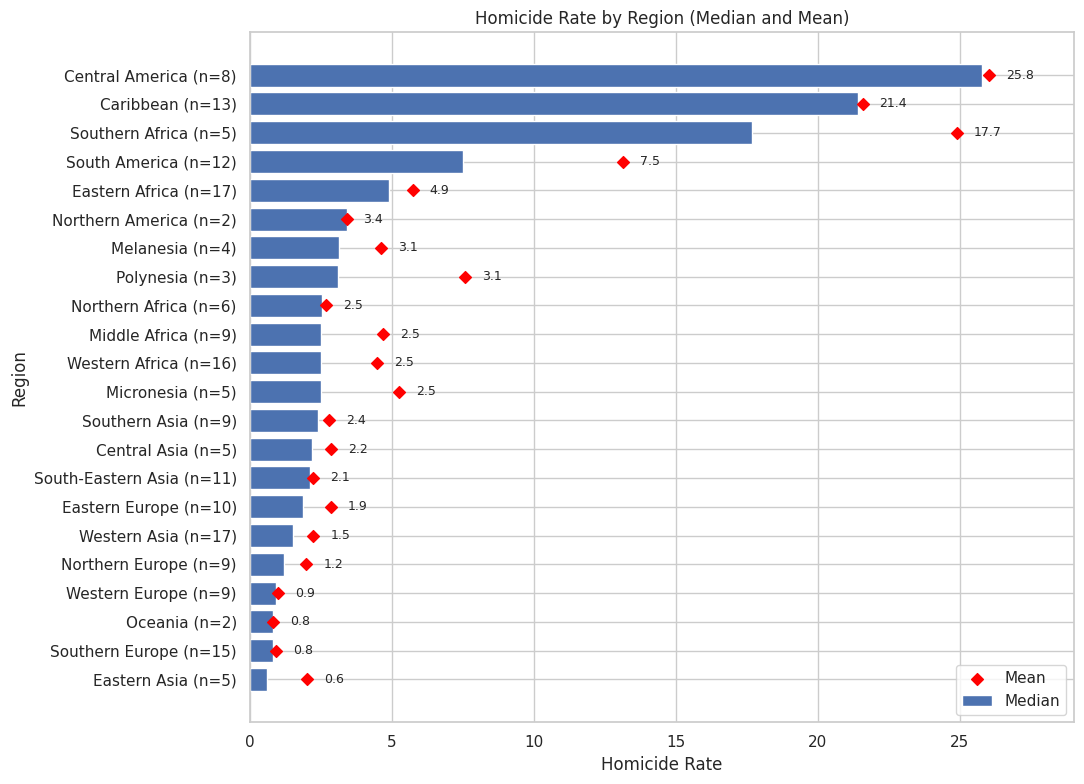

In [24]:
region_stats = (df.groupby('region')['homicide_rate']
                  .agg(['median', 'mean', 'count'])
                  .sort_values('median', ascending=False))

ylabels = [f'{r} (n={n})' for r, n in zip(region_stats.index, region_stats['count'])]
pos = np.arange(len(region_stats))

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(pos, region_stats['median'], color=sns.color_palette()[0], label='Median')
ax.scatter(region_stats['mean'], pos, color='red', marker='D', zorder=3, label='Mean')

for p, med, mean in zip(pos, region_stats['median'], region_stats['mean']):
    ax.text(max(med, mean) + 0.6, p, f'{med:.1f}', va='center', fontsize=9)

ax.set_xlim(0, region_stats[['median', 'mean']].max().max() + 3)

ax.set_yticks(pos)
ax.set_yticklabels(ylabels)
ax.invert_yaxis()
ax.set_title('Homicide Rate by Region (Median and Mean)')
ax.set_xlabel('Homicide Rate')
ax.set_ylabel('Region')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Observation:** region explains far more of the pattern than any single indicator. Four regions stand well above the rest by median homicide rate: Central America (25.8), the Caribbean (21.4), Southern Africa (17.7) and South America (7.5). Eastern Africa follows at 4.9, and every other region is at 3.4 or below, with Southern Europe (0.8), Western Europe (0.9) and Eastern Asia (0.6) the lowest. The gap between Central America and Western Europe is roughly 29 times. In Southern Africa and South America the mean is well above the median (24.9 vs 17.7 and 13.2 vs 7.5), showing that a few countries pull those regions up. These four regions also contain 19 of the 23 outlier countries found earlier. Note that the medians of exactly 2.5 for Middle Africa, Western Africa and Micronesia equal the dataset median, so they are likely placeholders rather than measured values.

**Sensitivity check:** do the conclusions change if the 26 countries with the repeated value of 2.5 are left out?

In [25]:
robust = df[df['homicide_rate'] != 2.5]
print(f'Countries kept: {len(robust)} of {len(df)}')
print(f"Outlier countries above the fence: {(robust['homicide_rate'] > upper_fence).sum()} (was {len(outliers)})")

sens = pd.DataFrame({
    'Spearman (all 192)': df[num_cols].corr(method='spearman')['homicide_rate'],
    'Spearman (excl. 2.5)': robust[num_cols].corr(method='spearman')['homicide_rate']
}).drop('homicide_rate').round(2).sort_values('Spearman (excl. 2.5)')

display(sens.head(5))
display(sens.tail(3))

robust.groupby('region')['homicide_rate'].median().sort_values(ascending=False).head(5)

Countries kept: 166 of 192
Outlier countries above the fence: 23 (was 23)


,Spearman (all 192),Spearman (excl. 2.5)
life_expectancy_male,-0.43,-0.48
life_expectancy_female,-0.39,-0.44
internet_users,-0.37,-0.42
gdp_per_capita,-0.33,-0.37
urban_population,-0.30,-0.32


,Spearman (all 192),Spearman (excl. 2.5)
unemployment,0.19,0.21
fertility,0.34,0.37
infant_mortality,0.41,0.46


region
Central America    25.80
Caribbean          21.40
Southern Africa    17.70
Micronesia          9.35
South America       7.50
Name: homicide_rate, dtype: float64

**Result:** the conclusions are robust. All 23 outlier countries remain, the top three regions (Central America, the Caribbean, Southern Africa) keep the same medians (25.8, 21.4, 17.7), and the correlations become slightly stronger rather than weaker (for example male life expectancy -0.43 to -0.48 and infant mortality +0.41 to +0.46). The repeated values therefore dilute the relationships a little but do not create them.

In [26]:
# Countries with the highest homicide rates
df.nlargest(10, 'homicide_rate')[['name', 'region', 'homicide_rate', 'unemployment', 'gdp_per_capita']]

,name,region,homicide_rate,unemployment,gdp_per_capita
52,El Salvador,Central America,52.0,4.2,4058.2
84,Jamaica,Caribbean,43.9,8.0,5354.3
97,Lesotho,Southern Africa,43.6,22.8,1248.0
73,Honduras,Central America,38.9,5.2,2500.1
17,Belize,Central America,37.8,6.4,4884.7
187,"Venezuela, Bolivarian Republic Of",South America,36.7,9.4,7212.2
146,Saint Vincent And The Grenadines,Caribbean,36.5,18.9,7361.3
160,South Africa,Southern Africa,36.4,28.5,6369.2
144,Saint Kitts And Nevis,Caribbean,36.1,5.4,19275.4
128,Nigeria,Western Africa,34.5,8.0,2153.5


## **Key Findings**

1. **Homicide is highly unequal across countries.** The distribution is right-skewed (skew 2.5): median 2.5 vs mean 6.5, with 23 outlier countries above a rate of 14.4 and a maximum of 52.0 (El Salvador).
2. **Most indicators are skewed, not bell-shaped.** GDP per capita, population, CO2 emissions and population density have long right tails, so medians describe a typical country better than means.
3. **Indicators overlap heavily with each other** (for example life expectancy, infant mortality, fertility and internet use), but homicide is only weakly correlated with each of them (|r| at most 0.24, |Spearman| at most 0.43).
4. **Higher homicide goes with weaker development on average:** lower life expectancy, higher infant mortality, lower GDP per capita and higher unemployment, but these are tendencies with wide scatter, not predictors.
5. **Geography is the strongest pattern.** Central America, the Caribbean, Southern Africa and South America hold 19 of the 23 outliers and have by far the highest regional medians. This supports treating region as the natural hotspot unit.
6. **Data quality needs attention.** 26 countries share a homicide rate of exactly 2.5 and 57 share the same CO2 value (31.3): both are the column median, consistent with median imputation. A sensitivity check without the 26 homicide rows leaves every conclusion unchanged (correlations get slightly stronger), but the source data for these countries should be verified.

## **Conclusion**

Week 4 completed the EDA deep dive on the cleaned dataset. The univariate analysis described the distribution of homicide rate, the spread of countries across regions and the shape of six key socio-economic indicators. The bivariate analysis then examined how homicide relates to those indicators and to region. The results show that homicide is concentrated in a small set of regions and countries and is not explained by any single socio-economic variable, which provides a clear foundation for the hotspot-focused analysis and dashboard work in the coming weeks. Before map-based work begins, the Namibia ISO-code error should be corrected and the repeated median values in the homicide and CO2 columns should be checked against the raw data.